In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy
%matplotlib inline
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [149]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred, average='macro')
    recall = recall_score(y_test , pred, average='macro')
    f1 = f1_score(y_test,pred, average='macro')
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba, multi_class='ovr', average='macro')
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

| 컬럼명              | 설명                                      | 타입      | 비고                                   |
|---------------------|-----------------------------------------|-----------|----------------------------------------|
| ID                  | 샘플별 고유 ID                           | 문자열     | 학습에 불필요, 제출 시 식별자로 사용   |
| age                 | 고객 나이                                | 수치형     | —                                      |
| gender              | 고객 성별                                | 범주형     | 예: M / F                              |
| tenure              | 고객이 서비스를 이용한 총 기간 (월)       | 수치형     | —                                      |
| frequent            | 고객의 서비스 이용일                     | 수치형     | —                                      |
| payment_interval    | 고객의 결제 지연일                       | 수치형     | —                                      |
| subscription_type   | 고객의 서비스 등급                       | 범주형     | 예: member, plus, vip                  |
| contract_length     | 고객의 서비스 계약 기간 (일)              | 수치/범주형 | 30, 90, 360 등                          |
| after_interaction   | 최근 서비스 이용으로부터 경과한 기간 (일) | 수치형     | —                                      |
| support_needs       | 고객의 지원 필요도 (0: 낮음, 1: 중간, 2: 높음) | 레이블     | **타깃 변수**                           |

In [150]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

train.head()

,ID,age,gender,tenure,frequent,payment_interval,subscription_type,contract_length,after_interaction,support_needs
0,TRAIN_00000,54.0,F,47.0,22.0,8.0,member,90,25.0,0
1,TRAIN_00001,30.0,M,16.0,15.0,5.0,vip,360,23.0,0
2,TRAIN_00002,29.0,M,8.0,30.0,21.0,plus,30,21.0,0
3,TRAIN_00003,38.0,F,38.0,23.0,10.0,vip,90,6.0,0
4,TRAIN_00004,25.0,F,52.0,3.0,17.0,member,30,1.0,2


In [151]:
print(train.shape, test.shape)
train.info()

(30858, 10) (13225, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30858 entries, 0 to 30857
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 30858 non-null  object 
 1   age                30858 non-null  float64
 2   gender             30858 non-null  object 
 3   tenure             30858 non-null  float64
 4   frequent           30858 non-null  float64
 5   payment_interval   30858 non-null  float64
 6   subscription_type  30858 non-null  object 
 7   contract_length    30858 non-null  int64  
 8   after_interaction  30858 non-null  float64
 9   support_needs      30858 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 2.4+ MB


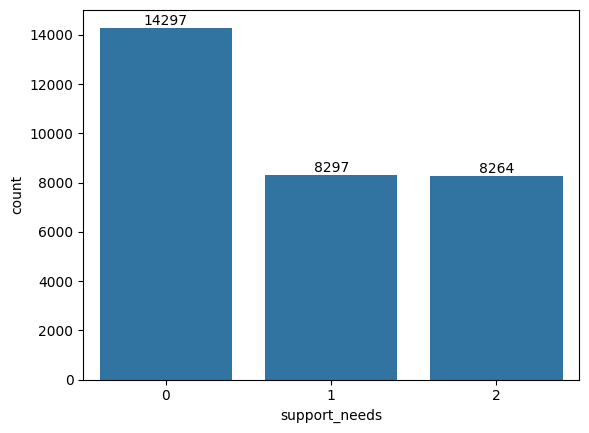

In [152]:
ax = sns.countplot(data=train, x = 'support_needs')
ax.bar_label(ax.containers[0])
plt.show()

In [153]:
print(train['support_needs'].value_counts())
total_cnt = train['support_needs'].count()
print('고객 지원 필요도 0의 비율은 {0:.4f}'.format(train['support_needs'].value_counts()[0] / total_cnt))
print('고객 지원 필요도 1의 비율은 {0:.4f}'.format(train['support_needs'].value_counts()[1] / total_cnt))
print('고객 지원 필요도 2의 비율은 {0:.4f}'.format(train['support_needs'].value_counts()[2] / total_cnt))

support_needs
0    14297
1     8297
2     8264
Name: count, dtype: int64
고객 지원 필요도 0의 비율은 0.4633
고객 지원 필요도 1의 비율은 0.2689
고객 지원 필요도 2의 비율은 0.2678


In [154]:
train.describe()

,age,tenure,frequent,payment_interval,contract_length,after_interaction,support_needs
count,30858.000000,30858.000000,30858.000000,30858.000000,30858.000000,30858.000000,30858.000000
mean,39.428479,31.250275,15.803876,12.947145,186.643010,14.546147,0.804492
std,12.423977,17.403133,8.612354,8.302702,143.948206,8.599893,0.832419
min,18.000000,1.000000,1.000000,0.000000,30.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,6.000000,90.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,12.000000,90.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,19.000000,360.000000,22.000000,2.000000
max,65.000000,60.000000,30.000000,30.000000,360.000000,30.000000,2.000000


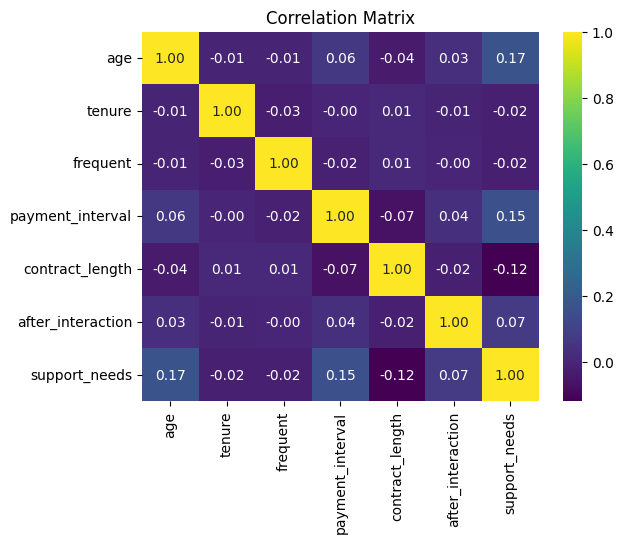

In [155]:
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

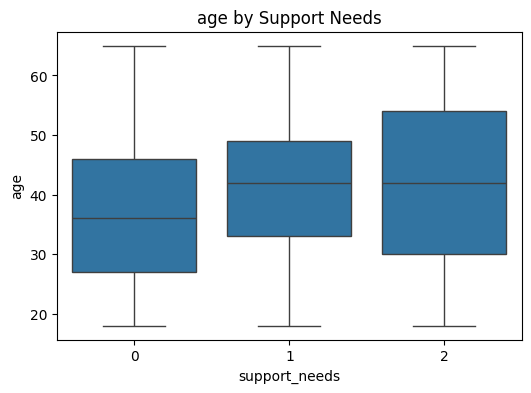

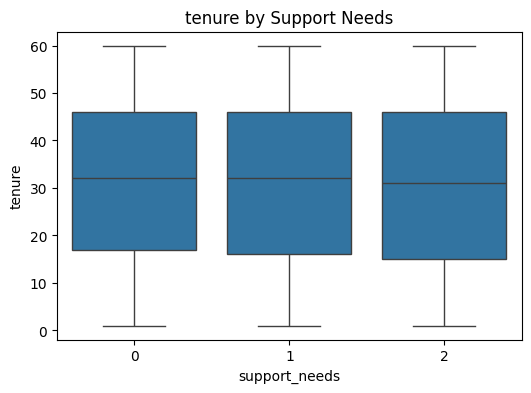

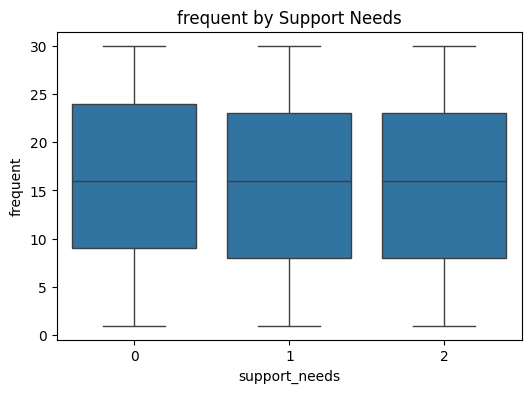

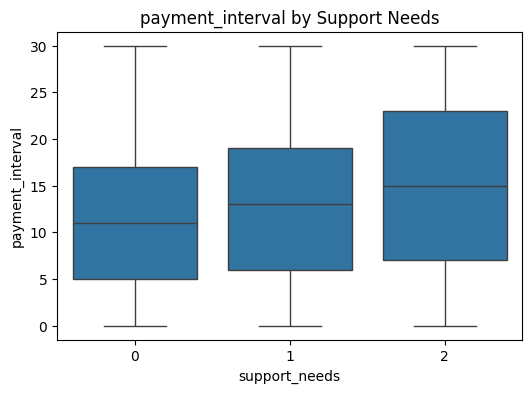

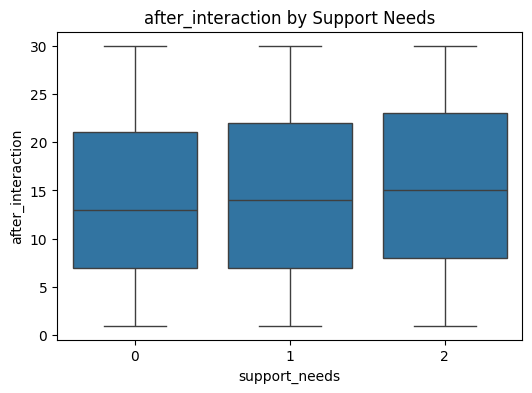

In [156]:
# 2) 수치형 변수 분포 by 타깃
num_cols = ["age", "tenure", "frequent", "payment_interval", "after_interaction"]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="support_needs", y=col, data=train)
    plt.title(f"{col} by Support Needs")
    plt.show()

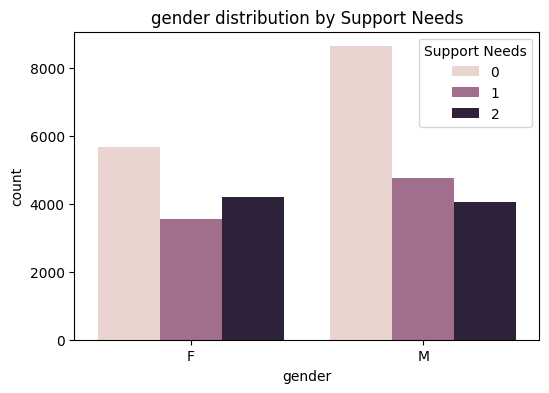

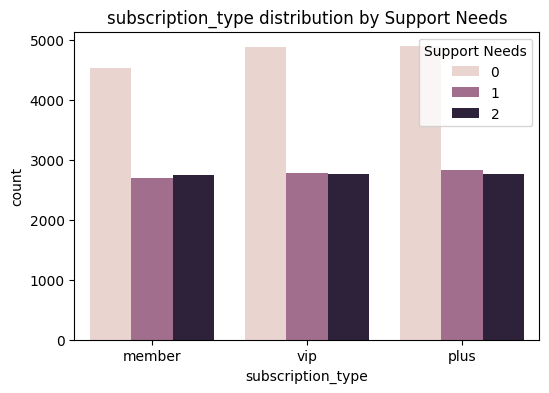

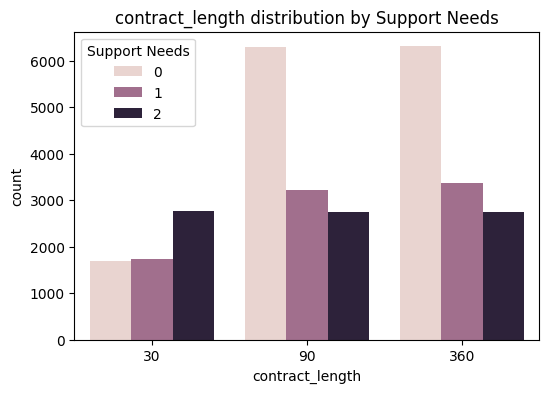

In [157]:
# 3) 범주형 변수 분포
cat_cols = ["gender", "subscription_type", "contract_length"]
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="support_needs", data=train)
    plt.title(f"{col} distribution by Support Needs")
    plt.legend(title="Support Needs")
    plt.show()

In [158]:
X = train.iloc[:, :-1]
y = train.iloc[:, -1]
X

,ID,age,gender,tenure,frequent,payment_interval,subscription_type,contract_length,after_interaction
0,TRAIN_00000,54.0,F,47.0,22.0,8.0,member,90,25.0
1,TRAIN_00001,30.0,M,16.0,15.0,5.0,vip,360,23.0
2,TRAIN_00002,29.0,M,8.0,30.0,21.0,plus,30,21.0
3,TRAIN_00003,38.0,F,38.0,23.0,10.0,vip,90,6.0
4,TRAIN_00004,25.0,F,52.0,3.0,17.0,member,30,1.0
...,...,...,...,...,...,...,...,...,...
30853,TRAIN_30853,48.0,M,5.0,10.0,12.0,vip,360,11.0
30854,TRAIN_30854,24.0,M,22.0,27.0,16.0,plus,360,1.0
30855,TRAIN_30855,46.0,M,6.0,3.0,14.0,vip,90,25.0
30856,TRAIN_30856,29.0,F,5.0,11.0,16.0,member,90,15.0


In [159]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # ID 제거
    df_copy.drop('ID', axis=1, inplace=True)
    
    # 성별을 숫자로 매핑 (M=0, F=1)
    df_copy['gender'] = df_copy['gender'].map({
        'M': 0,
        'F': 1
    })
    
    # 원-핫 인코딩 사용
    df_copy['subscription_type'] = df_copy['subscription_type'].map({
        'member' : 0,
        'plus' : 1,
        'vip' : 2
    })
    
    return df_copy

def get_train_test_dataset(df=None):
    
    df_copy = get_preprocessed_df(df)
    
    X = df_copy.iloc[:, :-1]
    y = df_copy['support_needs']
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=0)
    return X_train, X_val, y_train, y_val

In [160]:
X_train, X_val, y_train, y_val = get_train_test_dataset(train)

In [161]:
lr_clf = LogisticRegression(
    multi_class="multinomial",  # 다중 클래스
    solver="lbfgs",             # 안정적 최적화
    penalty="l2",               # L2 규제
    C=1.0,                      # 규제 강도 (튜닝 필요)
    class_weight="balanced",    # 불균형 자동 조정
    max_iter=1000,              # 충분한 반복
    random_state=42
)

In [185]:
std_scaler = StandardScaler()
std_scaler.fit_transform(X_train[['tenure']])

array([[ 1.24718099],
       [ 0.38532255],
       [-1.22347989],
       ...,
       [-0.30416421],
       [ 1.24718099],
       [ 1.01735207]], shape=(21600, 1))

In [192]:
test_df = get_preprocessed_df(test)
print(test_df.shape)
print(X_train.shape)
test_scaled = std_scaler.transform(test_df[['tenure']])
test['tenure_scaled'] = test_scaled
test_df.head()

(13225, 8)
(21600, 8)


,age,gender,tenure,frequent,payment_interval,subscription_type,contract_length,after_interaction
0,18.0,0,40.0,6.0,15.0,0,30,18.0
1,40.0,0,41.0,23.0,0.0,0,90,16.0
2,59.0,1,30.0,1.0,21.0,0,360,25.0
3,38.0,0,2.0,10.0,0.0,0,30,18.0
4,30.0,0,28.0,21.0,20.0,0,360,28.0


In [169]:
lr_clf.fit(X_train, y_train)

pred = lr_clf.predict(test_df)
submission = pd.DataFrame({"ID": test["ID"], "support_needs": pred.astype(int)})
submission.to_csv('submission.csv',index=False)
